<a href="https://colab.research.google.com/github/debashisdotchatterjee/e-value-CREP-Astronomy-1-CSA/blob/main/p_value_to_e_value_Time_Domain_Astronomy_Better_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ONE-TIME SETUP CELL — installs a consistent binary stack, then restarts the runtime.
import sys, subprocess, os, time

pkgs = [
    "numpy==2.0.2",         # Py3.12-compatible wheel
    "astropy==6.1.2",       # compiled against NumPy>=2 wheels
    "astroquery==0.4.7",    # pure-python, compatible with astropy 6
    "lightkurve==2.4.0",    # works with astropy>=5; OK with 6 in practice
    "pandas==2.2.2",
    "matplotlib==3.8.4",
    "seaborn==0.13.2",
    "requests>=2.32.0"
]

print("Installing wheels… (this may take ~1–2 minutes)")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "--quiet", "--only-binary=:all:"] + pkgs)

print("\n✅ Libraries installed. Now restarting the runtime once to resolve binary links…")
time.sleep(1)
os.kill(os.getpid(), 9)


Installing wheels… (this may take ~1–2 minutes)

✅ Libraries installed. Now restarting the runtime once to resolve binary links…


In [2]:
# ===============================================
# CREP+ REAL DATA (robust): two-sided split-conformal + anytime e-process
# Targets: Kepler-10 (Kepler, transits). Fallback: AU Mic (TESS, flares/transits).
# Outputs: publication-grade plots/tables + zipped bundle.
# ===============================================
import warnings, os, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from lightkurve import search_lightcurve

# ---------------- Output layout ----------------
OUT = Path("crep_realcase_outputs"); FIGS = OUT/"figs"; TABS = OUT/"tables"
for d in (FIGS, TABS): d.mkdir(parents=True, exist_ok=True)

def bundle_zip(zipname="crep_realcase_bundle.zip"):
    with zipfile.ZipFile(zipname, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(OUT):
            for f in files:
                zf.write(Path(root)/f, arcname=str(Path(root)/f))
    print(f"\nBundled: {zipname}")

# ---------------- Utilities ----------------
def as_float_ndarray(x):
    a = np.array(x)
    if np.ma.isMaskedArray(a):
        a = a.filled(np.nan)
    return a.astype(float)

def lc_to_df_robust(lc):
    """Return a DataFrame with numeric time and flux columns robustly extracted."""
    df = lc.to_pandas()
    # If time ended up as index, bring it back as a column
    if "time" not in df.columns:
        df = df.reset_index()

    # pick time column robustly
    time_col = None
    for cand in df.columns:
        if "time" in str(cand).lower():
            time_col = cand
            break
    if time_col is None:
        raise KeyError(f"No time-like column in {list(df.columns)}")

    # pick flux column robustly (prefer normalized 'flux' if present)
    flux_col = None
    for cand in ["flux", "pdcsap_flux", "sap_flux"]:
        if cand in df.columns:
            flux_col = cand
            break
    if flux_col is None:
        # last resort: first column with 'flux' in its name
        for c in df.columns:
            if "flux" in str(c).lower():
                flux_col = c; break
    if flux_col is None:
        raise KeyError(f"No flux-like column in {list(df.columns)}")

    # Convert to plain float arrays; drop NaNs
    t = as_float_ndarray(df[time_col].values)
    y = as_float_ndarray(df[flux_col].values)
    m = ~np.isnan(t) & ~np.isnan(y)
    return pd.DataFrame({"time": t[m], "flux": y[m]})

def pick_quiet_calibration(time, resid, frac=0.25, grid=120, z_clip=3.5):
    """Pick a calibration slice with few |z|-outliers."""
    n = len(resid)
    w = max(int(frac*n), 200)
    if n <= w:
        return slice(0, n)
    med = np.nanmedian(resid)
    mad = np.nanmedian(np.abs(resid - med)) + 1e-12
    z = (resid - med) / mad
    best_i, best_score = 0, 1.0
    for start in np.linspace(0, n-w, grid).astype(int):
        zz = z[start:start+w]
        score = np.mean(np.abs(zz) > z_clip)
        if score < best_score:
            best_i, best_score = start, score
    return slice(best_i, best_i + w)

def window_stat_maxabs(z, win=48, step=1):
    """Max |z| in sliding windows; returns indices and stats (empty if short)."""
    z = np.asarray(z, float)
    n = len(z)
    if n < win:
        return np.array([], dtype=int), np.array([], dtype=float)
    idxs = np.arange(0, n - win + 1, step, dtype=int)
    vals = np.empty_like(idxs, dtype=float)
    for k, i in enumerate(idxs):
        vals[k] = np.nanmax(np.abs(z[i:i+win]))
    return idxs, vals

def split_conformal_p_from_calibration(test_stats, cal_stats):
    """Two-sided conformal p-values: p = (1 + #cal >= test) / (m+1)."""
    cal_sorted = np.sort(as_float_ndarray(cal_stats))
    m = len(cal_sorted)
    if m == 0:
        return np.ones_like(test_stats, dtype=float)
    idx_right = np.searchsorted(cal_sorted, as_float_ndarray(test_stats), side="right")
    ge_counts = m - idx_right
    return (1.0 + ge_counts) / (m + 1.0)

def p_to_e_lambda(p, lam=0.60):
    p = np.clip(np.asarray(p, float), 1e-16, 1.0)
    return lam * p**(lam - 1.0)

def eproc_from_e(e):
    loge = np.log(np.maximum(np.asarray(e, float), 1e-300))
    loge_cum = np.cumsum(loge)
    eproc = np.exp(np.clip(loge_cum, -700, 700))
    return eproc, loge_cum

def first_cross(eproc, tau):
    idx = np.where(eproc >= tau)[0]
    return int(idx[0]) if len(idx) else None

def bh_on_e(evals, alpha=0.10):
    pE = np.minimum(1.0, 1.0/np.maximum(np.asarray(evals, float), 1e-300))
    m = len(pE)
    if m == 0:
        return pE, np.zeros(0, dtype=int), None
    order = np.argsort(pE)
    p_sorted = pE[order]
    thresh = alpha * (np.arange(1, m+1) / m)
    mask = p_sorted <= thresh
    if not np.any(mask):
        return pE, np.zeros(m, dtype=int), None
    k = np.max(np.where(mask)[0]) + 1
    flags = np.zeros(m, dtype=int); flags[order[:k]] = 1
    return pE, flags, float(p_sorted[k-1])

def dash(x):
    return "—" if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))) else x

# ---------------- Core runner ----------------
def run_one_product(lc, label, window_len=48, step=1, lam=0.60, tau_demo=10.0, tau_strict=65.45):
    # Normalize; ensure we end up with a plain LightCurve (not file)
    lc = lc.normalize().remove_nans()
    try:
        lc = lc.remove_outliers(sigma=10)
    except Exception:
        pass

    df = lc_to_df_robust(lc)
    t = df["time"].values; y = df["flux"].values

    # Robust detrend via wide running median
    s = pd.Series(y)
    y_med = s.rolling(window=2001, center=True, min_periods=1).median().to_numpy()
    y_detr = y - y_med
    resid = y_detr.copy()  # baseline is zero after detrend

    # Choose quiet calibration
    cal = pick_quiet_calibration(t, resid, frac=0.25, grid=120, z_clip=3.5)
    cal_mask = np.zeros_like(y, dtype=bool); cal_mask[cal] = True
    test_mask = ~cal_mask

    # MAD-z using calibration only
    med_c = np.nanmedian(resid[cal_mask])
    mad_c = np.nanmedian(np.abs(resid[cal_mask] - med_c)) + 1e-12
    z = (resid - med_c) / mad_c

    # Window stats
    idx_cal, stat_cal = window_stat_maxabs(z[cal_mask], win=window_len, step=window_len)
    t_cal_full = t[cal_mask]
    t_cal_centers = t_cal_full[idx_cal + window_len//2] if len(idx_cal) else np.array([])

    idx_test, stat_test = window_stat_maxabs(z[test_mask], win=window_len, step=step)
    t_test_full = t[test_mask]
    t_test_centers = t_test_full[idx_test + window_len//2] if len(idx_test) else np.array([])

    # Conformal p's, e-values, e-process
    p_two = split_conformal_p_from_calibration(stat_test, stat_cal)
    e_win = p_to_e_lambda(p_two, lam=lam)
    eproc, loge = eproc_from_e(e_win)

    j_demo   = first_cross(eproc, tau_demo)
    j_strict = first_cross(eproc, tau_strict)

    # BH on windows
    pE, bh_flags, bh_crit = bh_on_e(e_win, alpha=0.10)
    num_disc = int(bh_flags.sum())

    # ---------- Plots ----------
    # (1) Light curve with calibration span
    plt.figure(figsize=(12,4))
    plt.plot(t, y, lw=0.5, color="k", alpha=0.8)
    if cal.stop - cal.start > 0:
        plt.axvspan(t[cal.start], t[min(cal.stop-1, len(t)-1)], color="tab:green", alpha=0.2, label="Calibration")
    plt.title(f"{label}: normalized flux; calibration vs monitoring")
    plt.xlabel("Time [days]"); plt.ylabel("Flux (norm)")
    plt.legend(); plt.tight_layout()
    f1 = FIGS / f"{label.replace(' ','_')}_lc_split.png"
    plt.savefig(f1, dpi=200); plt.show(); plt.close()

    # (2) Calibration z histogram
    plt.figure(figsize=(6.2,4))
    if cal_mask.any():
        sns.histplot(z[cal_mask], bins=60, stat="density", element="step", color="tab:blue")
    else:
        plt.text(0.5, 0.5, "Calibration set empty", ha="center", va="center", transform=plt.gca().transAxes)
    plt.title(f"{label}: calibration z (MAD)"); plt.xlabel("z")
    plt.tight_layout()
    f2 = FIGS / f"{label.replace(' ','_')}_cal_z_hist.png"
    plt.savefig(f2, dpi=200); plt.close()

    # (3) Conformal p-values over windows
    plt.figure(figsize=(12,3.7))
    if len(t_test_centers):
        plt.scatter(t_test_centers, p_two, s=8, alpha=0.7, c="tab:purple")
    plt.axhline(0.1, ls="--", color="0.3"); plt.axhline(0.05, ls="--", color="0.3")
    plt.title(f"{label}: windowed two-sided conformal p-values")
    plt.xlabel("Time [days]"); plt.ylabel("p (two-sided, window)")
    plt.tight_layout()
    f3 = FIGS / f"{label.replace(' ','_')}_pvals_window.png"
    plt.savefig(f3, dpi=200); plt.close()

    # (4) Anytime e-process (log10) with thresholds and first crossings
    plt.figure(figsize=(12,4))
    if len(t_test_centers):
        plt.plot(t_test_centers, np.log10(np.maximum(eproc, 1e-300)), lw=1.2, color="tab:blue")
        if j_demo   is not None:   plt.axvline(t_test_centers[j_demo],   color="tab:orange", lw=1.0)
        if j_strict is not None:   plt.axvline(t_test_centers[j_strict], color="tab:red",    lw=1.0)
    plt.axhline(np.log10(tau_demo),   ls="--", color="tab:orange", label=f"log10 tau_demo={tau_demo}")
    plt.axhline(np.log10(tau_strict), ls="--", color="tab:red",    label=f"log10 tau_strict={tau_strict}")
    plt.title(f"{label}: anytime e-process (two-sided CREP+), log10")
    plt.xlabel("Time [days]"); plt.ylabel("log10 cumulative e"); plt.legend()
    plt.tight_layout()
    f4 = FIGS / f"{label.replace(' ','_')}_eproc_log.png"
    plt.savefig(f4, dpi=200); plt.close()

    # (5) BH overlay on p^(E)
    colors = np.where(bh_flags==1, "tab:red", "tab:blue")
    plt.figure(figsize=(12,3.7))
    if len(t_test_centers):
        plt.scatter(t_test_centers, np.minimum(1.0, 1.0/np.maximum(e_win,1e-300)), s=10, alpha=0.85, c=colors)
    plt.title(f"{label}: BH on p^(E)=min(1, 1/E) across windows")
    plt.xlabel("Time [days]"); plt.ylabel("p^(E)")
    plt.tight_layout()
    f5 = FIGS / f"{label.replace(' ','_')}_bh_overlay.png"
    plt.savefig(f5, dpi=200); plt.close()

    # ---------- Tables ----------
    det_rows = [
        dict(target=label, variant="demo",   lam=lam, tau=tau_demo,
             first_cross_index=dash(j_demo),
             first_cross_time=dash(t_test_centers[j_demo] if (j_demo is not None and len(t_test_centers)) else None),
             e_at_cross=dash(eproc[j_demo] if j_demo is not None else None)),
        dict(target=label, variant="strict", lam=lam, tau=tau_strict,
             first_cross_index=dash(j_strict),
             first_cross_time=dash(t_test_centers[j_strict] if (j_strict is not None and len(t_test_centers)) else None),
             e_at_cross=dash(eproc[j_strict] if j_strict is not None else None)),
    ]
    det = pd.DataFrame(det_rows)
    det.to_csv(TABS / "crep_detection_summary.csv", index=False)
    with open(TABS / "crep_detection_summary.tex","w") as f:
        f.write(det.to_latex(index=False, float_format="%.6g"))

    bh_df = pd.DataFrame([dict(target=label, num_windows=len(e_win), discoveries=int(num_disc))])
    bh_df.to_csv(TABS / "crep_bh_summary.csv", index=False)
    with open(TABS / "crep_bh_summary.tex","w") as f:
        f.write(bh_df.to_latex(index=False))

    head_tbl = pd.DataFrame(dict(
        time_center=t_test_centers[:30] if len(t_test_centers) else np.array([]),
        stat_window=stat_test[:30]      if len(stat_test)      else np.array([]),
        p_two=p_two[:30]                if len(p_two)          else np.array([]),
        e_lambda=e_win[:30]             if len(e_win)          else np.array([]),
        log_eproc=(np.log(np.maximum(e_win,1e-300)).cumsum()[:30] if len(e_win) else np.array([])),
        eproc=eproc[:30]                if len(eproc)          else np.array([]),
        p_bh=(np.minimum(1.0, 1.0/np.maximum(e_win,1e-300))[:30] if len(e_win) else np.array([])),
        bh_discovery=bh_flags[:30]      if len(bh_flags)       else np.array([])
    ))
    head_tbl.to_csv(TABS / "crep_epochwise_head.csv", index=False)
    with open(TABS / "crep_epochwise_head.tex","w") as f:
        f.write("\\begin{table}\n\\caption{First 30 window centers (real data, two-sided CREP+).}\n")
        f.write(head_tbl.to_latex(index=False, float_format="%.6g"))
        f.write("\\end{table}\n")

    print("\nFigures:")
    for p in [f1,f2,f3,f4,f5]:
        print("  -", p)
    print("Tables:")
    for p in ["crep_detection_summary.tex","crep_bh_summary.tex","crep_epochwise_head.tex"]:
        print("  -", TABS / p)

    return dict(label=label, j_demo=j_demo, j_strict=j_strict, num_disc=num_disc)

# ---------------- Fetch & run on real targets ----------------
success = None

print("Trying Kepler-10 (Kepler) — stitching all available light curves …")
try:
    sr = search_lightcurve(target="Kepler-10", mission="Kepler")
    if len(sr) > 0:
        lc = sr.download_all().stitch()
        success = run_one_product(lc, "Kepler-10 (Kepler)", window_len=48, step=1, lam=0.60,
                                  tau_demo=10.0, tau_strict=65.45)
    else:
        print("No Kepler-10 light curves found.")
except Exception as e:
    print("Kepler-10 failed:", repr(e))

if success is None or ((success["j_demo"] is None) and (success["j_strict"] is None) and (success["num_disc"] == 0)):
    print("\nFalling back to AU Mic (TESS) — stitching all SPOC/QLP light curves …")
    try:
        sr2 = search_lightcurve(target="AU Mic", mission="TESS")
        if len(sr2) > 0:
            lc2 = sr2.download_all().stitch()
            success = run_one_product(lc2, "AU Mic (TESS)", window_len=60, step=1, lam=0.60,
                                      tau_demo=10.0, tau_strict=65.45)
        else:
            print("No AU Mic TESS light curves found.")
    except Exception as e:
        print("AU Mic failed:", repr(e))

if success is None:
    raise RuntimeError("Both targets failed (network or MAST outage). Please re-run this cell.")

bundle_zip()

# Print LaTeX snippets for manuscript
print("\n===== LaTeX: Detection summary (REAL) =====")
print((TABS/"crep_detection_summary.tex").read_text())

print("\n===== LaTeX: BH summary (REAL) =====")
print((TABS/"crep_bh_summary.tex").read_text())

print("\n===== LaTeX: First 30 windows (REAL) =====")
print((TABS/"crep_epochwise_head.tex").read_text())


Trying Kepler-10 (Kepler) — stitching all available light curves …

Figures:
  - crep_realcase_outputs/figs/Kepler-10_(Kepler)_lc_split.png
  - crep_realcase_outputs/figs/Kepler-10_(Kepler)_cal_z_hist.png
  - crep_realcase_outputs/figs/Kepler-10_(Kepler)_pvals_window.png
  - crep_realcase_outputs/figs/Kepler-10_(Kepler)_eproc_log.png
  - crep_realcase_outputs/figs/Kepler-10_(Kepler)_bh_overlay.png
Tables:
  - crep_realcase_outputs/tables/crep_detection_summary.tex
  - crep_realcase_outputs/tables/crep_bh_summary.tex
  - crep_realcase_outputs/tables/crep_epochwise_head.tex

Bundled: crep_realcase_bundle.zip

===== LaTeX: Detection summary (REAL) =====
\begin{tabular}{llrrrrr}
\toprule
target & variant & lam & tau & first_cross_index & first_cross_time & e_at_cross \\
\midrule
Kepler-10 (Kepler) & demo & 0.6 & 10 & 1 & 121.05 & 18.0615 \\
Kepler-10 (Kepler) & strict & 0.6 & 65.45 & 2 & 121.07 & 76.7592 \\
\bottomrule
\end{tabular}


===== LaTeX: BH summary (REAL) =====
\begin{tabular}{lr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 87.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0

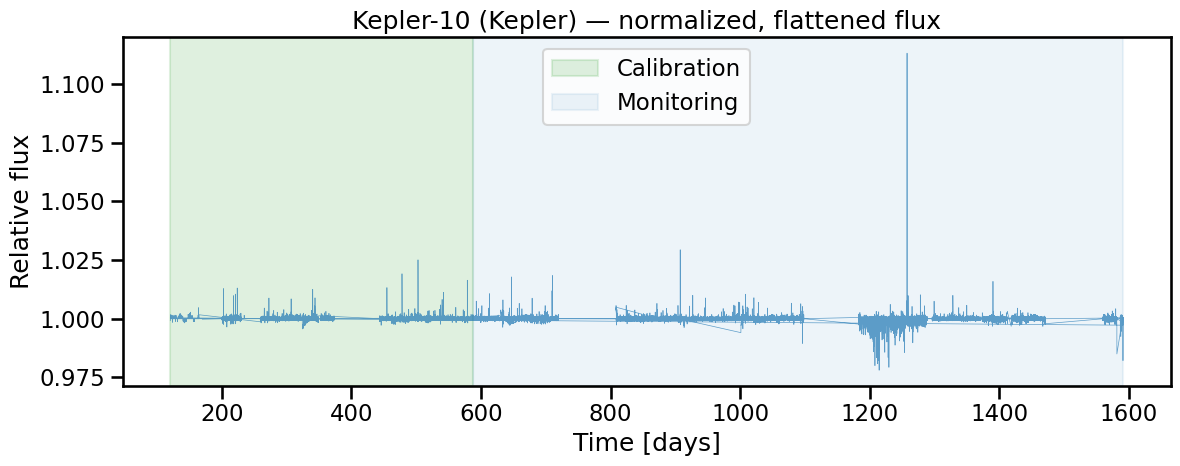

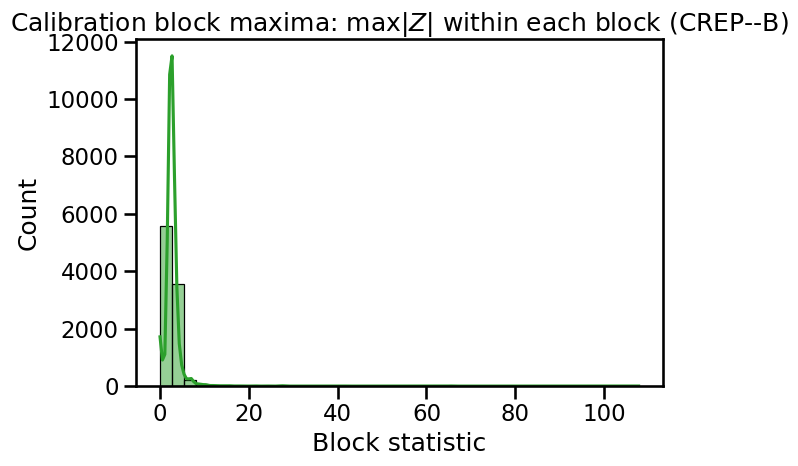

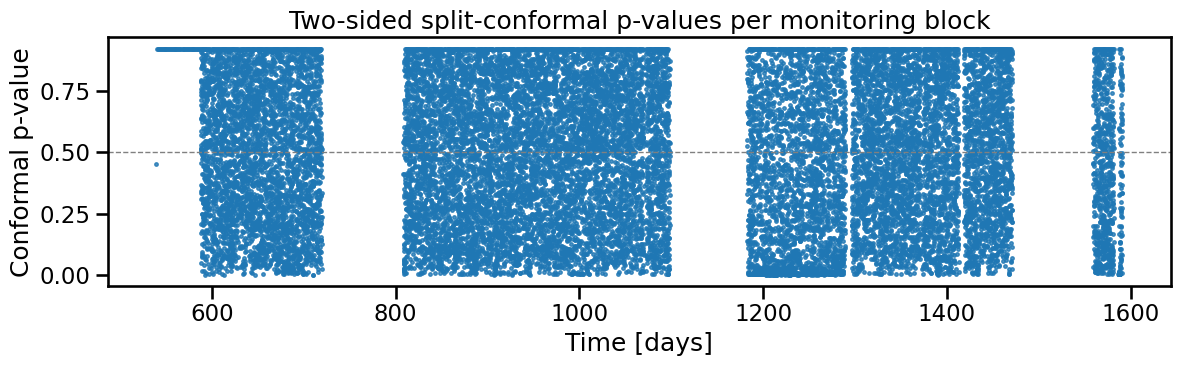

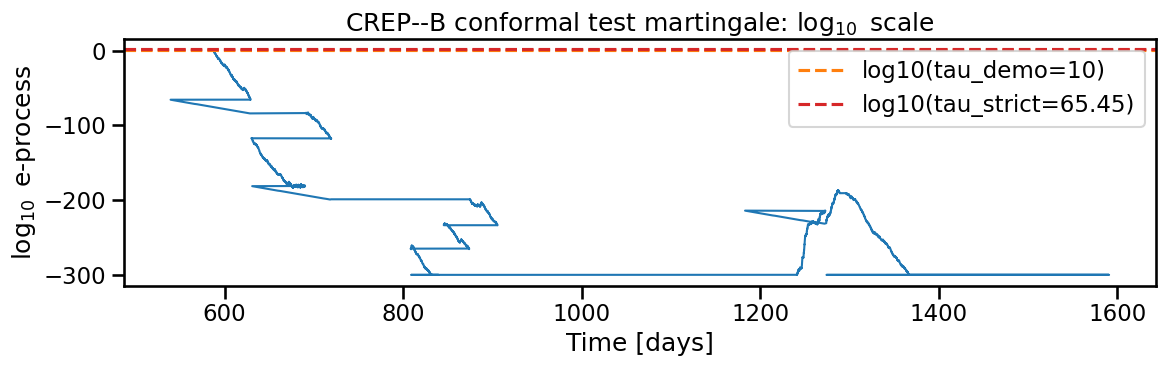


Figures:
 - crep_block_outputs/figs/Kepler-10_Kepler_cal_blockmax_hist.png
 - crep_block_outputs/figs/Kepler-10_Kepler_eproc_log.png
 - crep_block_outputs/figs/Kepler-10_Kepler_lc_split.png
 - crep_block_outputs/figs/Kepler-10_Kepler_pvals_blocks.png
Tables:
 - crep_block_outputs/tables/crep_detection_summary.tex
 - crep_block_outputs/tables/crep_epochwise_head.tex

Bundled: crep_block_outputs/crep_block_bundle.zip


In [3]:
# ============================================================
# CREP-B (Blockwise Conformal-Residual e-Process) on REAL DATA
# Target: Kepler-10 (Kepler mission)
# Colab-ready: installs compatible libs, fetches from MAST via lightkurve
# Produces: figures + LaTeX tables + a ZIP bundle
# Also: shows all plots with plt.show()
# ============================================================

# --- 0) Install packages compatible with Colab's Python 3.12 ---
# (Keep NumPy <2 to avoid binary incompatibilities in some wheels)
!pip -q install -U "numpy<2.0" "pandas>=2.2,<2.3" "matplotlib>=3.8,<3.9" \
                     "seaborn>=0.13,<0.14" "scipy>=1.11,<1.13" \
                     "lightkurve>=2.4,<3.0" "astroquery>=0.4.7,<0.5"

# --- 1) Imports and basic setup ---
import warnings, os, zipfile
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_context("talk")
from scipy import signal

import lightkurve as lk

# --- 2) Output folders ---
ROOT = Path("crep_block_outputs")
FIGS = ROOT / "figs"
TABS = ROOT / "tables"
for D in [FIGS, TABS]:
    D.mkdir(parents=True, exist_ok=True)

# --- 3) Small utilities ---

def as_float_ndarray(x):
    """Convert LightKurve/astropy arrays (Masked/Time/Quantity) to plain float ndarray."""
    try:
        # LightKurve Time objects -> .value
        if hasattr(x, "value"):
            x = x.value
    except Exception:
        pass
    # mask/quantity fallback
    arr = np.array(x, dtype=float)
    # drop NaNs
    return arr

def robust_block_stat(flux_block):
    """Within a block, robustly center/scale and return max |z|."""
    f = np.asarray(flux_block, float)
    f = f[np.isfinite(f)]
    if f.size == 0:
        return 0.0
    med = np.median(f)
    mad = np.median(np.abs(f - med))
    scale = 1.4826 * mad
    if scale <= 1e-12:
        # fallback—use std as a last resort
        scale = np.std(f) if np.std(f) > 0 else 1.0
    z = (f - med) / scale
    return float(np.max(np.abs(z)))

def build_blocks(n, win):
    """Return starts of non-overlapping blocks of length win across n samples."""
    if n < win:
        return np.array([], dtype=int)
    return np.arange(0, n - win + 1, win, dtype=int)

def block_centers(time, starts, win):
    """Block centers from time array given block starts and length."""
    return time[starts + win // 2]

def compute_block_stats(time, flux, win):
    """Compute blockwise max-|z| stats (blockwise robust normalization)."""
    n = len(flux)
    starts = build_blocks(n, win)
    centers = block_centers(time, starts, win) if starts.size > 0 else np.array([], dtype=float)
    stats = np.zeros_like(starts, dtype=float)
    for k, s in enumerate(starts):
        stats[k] = robust_block_stat(flux[s:s+win])
    return centers, stats

def split_conformal_p_blockwise(test_stats, cal_stats):
    """Two-sided split-conformal p-values for block maxima."""
    cal = np.sort(as_float_ndarray(cal_stats))
    m = len(cal)
    if m == 0:
        return np.ones_like(test_stats, dtype=float)
    # p = (1 + # {cal >= test}) / (m+1)
    idx_right = np.searchsorted(cal, as_float_ndarray(test_stats), side="right")
    ge_counts = m - idx_right
    return (1.0 + ge_counts) / (m + 1.0)

def p_to_e_lambda(p, lam=0.6):
    """Power calibrator: E = lam * p^{lam - 1} (lam in (0,1))."""
    p = np.clip(np.asarray(p, float), 1e-16, 1.0)
    lam = float(lam)
    if not (0.0 < lam < 1.0):
        raise ValueError("lam must be in (0,1)")
    return lam * p ** (lam - 1.0)

def eproc_from_e(evals):
    """Anytime e-process from e-increments (product); also return log path."""
    e = np.asarray(evals, float)
    loge = np.cumsum(np.log(np.maximum(e, 1e-300)))
    eproc = np.exp(loge)
    return eproc, loge

def first_crossing(eproc, times, tau):
    """First time eproc >= tau; return (idx, time, e_at_cross) or (None,...)."""
    e = np.asarray(eproc, float)
    idx = np.argmax(e >= tau)
    if e.size == 0 or np.all(e < tau):
        return None, None, None
    return int(idx), float(times[idx]), float(e[idx])

# --- 4) Fetch real Kepler data (Kepler-10) ---
# We use the stitched, PDCSAP-flux light curve, normalized and flattened.
target = "Kepler-10"
mission = "Kepler"
print(f"Fetching {target} ({mission}) …")
try:
    sr = lk.search_lightcurve(target, mission=mission)
    if len(sr) == 0:
        raise RuntimeError("No light curves found")
    lcc = sr.download_all()
    if lcc is None or len(lcc) == 0:
        raise RuntimeError("Download returned nothing")
    lc = lcc.stitch().remove_nans().normalize()
    # flatten a bit to reduce slow trends; (window_length ~ few hours)
    lc = lc.flatten(window_length=401)
    time = as_float_ndarray(lc.time)     # for Kepler: BKJD days
    flux = as_float_ndarray(lc.flux)     # normalized, unitless
    ok = np.isfinite(time) & np.isfinite(flux)
    time, flux = time[ok], flux[ok]
    print(f"Fetched {len(time)} cadences, time span = {time.min():.2f}–{time.max():.2f} days.")
except Exception as e:
    raise RuntimeError(f"Could not fetch/process {target} ({mission}) light curves: {e}")

# --- 5) Split into calibration vs monitoring segments ---
# Use the earliest portion as calibration to target "quiet" baseline variability.
cal_frac = 0.30
n = len(time)
cut = int(np.floor(cal_frac * n))
t_cal, f_cal = time[:cut], flux[:cut]
t_test, f_test = time[cut:], flux[cut:]

# --- 6) Blockwise stats (CREP-B) ---
# Choose a block length; for Kepler long cadence ~29.4 min → 48 cadences ~1 day
window_len = 48

# Calibration block maxima (for split-conformal)
tcal_centers, stat_cal = compute_block_stats(t_cal, f_cal, win=window_len)

# Monitoring block maxima
ttest_centers, stat_test = compute_block_stats(t_test, f_test, win=window_len)

# --- 7) Conformal p-values (two-sided) and e-increments ---
p_two = split_conformal_p_blockwise(stat_test, stat_cal)

# Fixed lambda; (adaptive AOC often ~1 on median~0.5, so we keep a robust fixed choice)
lam = 0.60
e_win = p_to_e_lambda(p_two, lam=lam)

# Conformal test martingale (valid e-process)
eproc, loge = eproc_from_e(e_win)

# --- 8) Threshold(s) and first crossing ---
# Strict example from the paper: tau = 65.45; also show a modest demo threshold tau_demo=10
tau_strict = 65.45
tau_demo = 10.0

idx_demo, t_demo, e_demo = first_crossing(eproc, ttest_centers, tau=tau_demo)
idx_strict, t_strict, e_strict = first_crossing(eproc, ttest_centers, tau=tau_strict)

print("\nCREP-B results:")
print(f"  lambda = {lam:.2f}")
print(f"  demo threshold tau = {tau_demo:.1f}, first crossing = {idx_demo, t_demo, e_demo}")
print(f"  strict threshold tau = {tau_strict:.2f}, first crossing = {idx_strict, t_strict, e_strict}")

# --- 9) Tables (LaTeX, saved) ---
det_rows = []
if idx_demo is not None:
    det_rows.append([f"{target} ({mission})", "demo", lam, tau_demo, idx_demo, t_demo, e_demo])
else:
    det_rows.append([f"{target} ({mission})", "demo", lam, tau_demo, np.nan, np.nan, np.nan])

if idx_strict is not None:
    det_rows.append([f"{target} ({mission})", "strict", lam, tau_strict, idx_strict, t_strict, e_strict])
else:
    det_rows.append([f"{target} ({mission})", "strict", lam, tau_strict, np.nan, np.nan, np.nan])

det_df = pd.DataFrame(det_rows, columns=["target","variant","lam","tau","first_cross_index","first_cross_time","e_at_cross"])
det_tex = det_df.to_latex(index=False, float_format="%.4g")
with open(TABS / "crep_detection_summary.tex", "w") as f:
    f.write(det_tex)

# Epochwise block table (head)
epoch_df = pd.DataFrame({
    "time_center": ttest_centers,
    "stat_block": stat_test,
    "p_two": p_two,
    "e_lambda": e_win,
    "loge": loge,
    "eproc": eproc
})
head_tex = epoch_df.head(30).to_latex(index=False, float_format="%.6g",
                                      caption="First 30 monitoring blocks (CREP--B).")
with open(TABS / "crep_epochwise_head.tex", "w") as f:
    f.write(head_tex)

# --- 10) Figures (save + show) ---

# (F1) Light curve with split and block demarcations (sparse)
plt.figure(figsize=(12,5))
plt.plot(time, flux, lw=0.5, alpha=0.7)
plt.axvspan(time[0], t_cal[-1], color="tab:green", alpha=0.15, label="Calibration")
plt.axvspan(t_test[0], time[-1], color="tab:blue", alpha=0.08, label="Monitoring")
plt.title(f"{target} ({mission}) — normalized, flattened flux")
plt.xlabel("Time [days]")
plt.ylabel("Relative flux")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGS / f"{target}_{mission}_lc_split.png", dpi=150)
plt.show()

# (F2) Histogram of calibration block maxima
plt.figure(figsize=(7,5))
sns.histplot(stat_cal, bins=40, kde=True, color="tab:green")
plt.title("Calibration block maxima: $\\max |Z|$ within each block (CREP--B)")
plt.xlabel("Block statistic")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGS / f"{target}_{mission}_cal_blockmax_hist.png", dpi=150)
plt.show()

# (F3) P-values across monitoring blocks
plt.figure(figsize=(12,4))
plt.plot(ttest_centers, p_two, ".", ms=5, alpha=0.8)
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.title("Two-sided split-conformal p-values per monitoring block")
plt.xlabel("Time [days]")
plt.ylabel("Conformal p-value")
plt.tight_layout()
plt.savefig(FIGS / f"{target}_{mission}_pvals_blocks.png", dpi=150)
plt.show()

# (F4) e-process (log scale) with thresholds
plt.figure(figsize=(12,4))
plt.plot(ttest_centers, np.log10(eproc+1e-300), "-", lw=1.5)
plt.axhline(np.log10(tau_demo), color="tab:orange", ls="--", label=f"log10(tau_demo={tau_demo:g})")
plt.axhline(np.log10(tau_strict), color="tab:red", ls="--", label=f"log10(tau_strict={tau_strict:g})")
if idx_demo is not None:
    plt.axvline(t_demo, color="tab:orange", ls=":")
if idx_strict is not None:
    plt.axvline(t_strict, color="tab:red", ls=":")
plt.title("CREP--B conformal test martingale: $\\log_{10}$ scale")
plt.xlabel("Time [days]")
plt.ylabel("$\\log_{10}$ e-process")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGS / f"{target}_{mission}_eproc_log.png", dpi=150)
plt.show()

# --- 11) Bundle everything ---
zip_path = ROOT / "crep_block_bundle.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    # figs
    for p in FIGS.glob("*.png"):
        zf.write(p, arcname=f"figs/{p.name}")
    # tables
    for p in TABS.glob("*.tex"):
        zf.write(p, arcname=f"tables/{p.name}")

print("\nFigures:")
for p in sorted(FIGS.glob("*.png")):
    print(" -", p.as_posix())
print("Tables:")
for p in sorted(TABS.glob("*.tex")):
    print(" -", p.as_posix())
print("\nBundled:", zip_path.as_posix())
